# VRP

## Install

In [8]:
!pip install matplotlib 
# ==3.1.3
!pip install "qiskit[all]" 
# ==0.26.0
!pip install qiskit-optimization
!pip install cplex
!pip install pygsp
!pip install networkx
!pip install dwave-ocean-sdk
!pip install pulp

!git clone https://github.com/loukasa/graph-coarsening.git && cd graph-coarsening && pip install .

^C


fatal: destination path 'graph-coarsening' already exists and is not an empty directory.


## Imports

In [37]:
# Load the packages that are required
import numpy as np
import operator, random
import networkx as nx
import matplotlib.pyplot as plt
import pulp as pl
import math

import sys

if sys.version_info < (3, 6):
    raise Exception("Please use Python version 3.6 or greater.")

try:
    import cplex
    from cplex.exceptions import CplexError
except:
    print("Warning: Cplex not found.")
import math

# Qiskit packages
from qiskit import BasicAer
from qiskit.quantum_info import Pauli
from qiskit.utils import QuantumInstance, algorithm_globals
from qiskit.algorithms import NumPyMinimumEigensolver, VQE
from qiskit.circuit.library import TwoLocal
from qiskit.algorithms.optimizers import SPSA

In [38]:
solver_list = pl.listSolvers(onlyAvailable=True)
solver_list

['CPLEX_PY', 'GUROBI_CMD', 'PULP_CBC_CMD']

In [241]:
# Initialize the problem by defining the parameters
n = 20  # number of nodes + depot (n+1)
K = 5   # number of vehicles
r = 0.2 # the extend of dimensionality reduction (r=0 means no reduction)

k = K - 1 # The size of the subspace we are interested in preserving
kmax = 2*min(K, 5) # Until which eigenvalue we are interested in

## Data Generator

In [242]:
def randomcolor():
    """ shnsye"""
    R, G, B, A = 0, 0, 0, 0
    R = random.randint(50, 125)
    G = random.randint(100, 175)
    B = random.randint(150, 220)
    A = (random.random() + 3) / 4
    return ('#{:2X}{:2X}{:2X}').format(R, G, B).replace(" ", "0"), A

In [243]:
import math

def distance(p1, p2):
    """Calculate the euclidian distance between two points in an 2D plane"""
    (x1, y1) = p1
    (x2, y2) = p2
    dist = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    return dist

def special_test_case_graph(N=(5, 6), verbose=False, as_initializer=False):
    G = nx.Graph()
    last_nodes = 0
    connectors = []

    for n in N:
        # Create 2 graphs
        H = nx.complete_graph(n)
        nodes = [n + last_nodes for n in H.nodes]
        edges = [ (n1+last_nodes, n2+last_nodes) for (n1, n2) in H.edges ]

        G.update(edges=edges, nodes=nodes)

        # Connect the graphs
        if last_nodes > 0:
            for i in range(random.randint(1, n)):
                added = False
                while not added:
                    old_n = len(G.nodes) - len(nodes)
                    new_n = len(nodes)
                    N1 = random.randint(0, old_n-1)
                    N2 = random.randint(old_n, len(G.nodes)-1)
                    if N1 != N2 and (N1, N2) not in connectors:
                        G.add_edge(N1, N2)
                        connectors += [ (N1, N2) ]
                        added = True

        last_nodes = len(nodes) + last_nodes
        
        pos = nx.spring_layout(G, seed=7)  # positions for all nodes - seed for reproducibility
        for (n1, n2) in G.edges:
            G[n1][n2]['weight'] = distance( pos[n1], pos[n2] )

    pos = nx.spring_layout(G, iterations=500, center=[0, 0], seed=7)  # positions for all nodes - seed for reproducibility
    for (n1, n2) in G.edges:
        G[n1][n2]['weight'] = distance( pos[n1], pos[n2] )

    # pos = nx.spring_layout(G, iterations=100, seed=7)
    if as_initializer :
        xc = [coord[0] for coord in pos.values()]
        yc = [coord[1] for coord in pos.values()]
        return ( xc, yc, nx.adjacency_matrix(G).todense() )

    if verbose:
        return (G, connectors)
    
    return G


In [ ]:
# # Test
# nodelist = (5, 3, 8, 2, 7)
# G, conn = special_test_case_graph(N=nodelist, verbose=True)

# normal = [(u, v) for (u, v, d) in G.edges(data=True) if ((u, v) not in conn) and ((v, u) not in conn)]
# conn   = conn

# pos = nx.spring_layout(G, iterations=100, seed=7)

# print()
# print(conn)
# print()

# # nodes
# i = 0
# for n in nodelist:
#     #"1f78b4"
#     color, alpha = randomcolor()
#     print([N for N in range(i, i+n)])
#     nx.draw_networkx_nodes(G, pos, nodelist=range(i, i+n), node_color=color, alpha=alpha, node_size=700)
#     i += n

# # edges
# nx.draw_networkx_edges(G, pos, edgelist=normal, width=1)
# nx.draw_networkx_edges(
#     G, pos, edgelist=conn, width=2, alpha=0.5, edge_color="b", style="dashed"
# )

# # nx.draw_networkx_edges(G, pos, edgelist=G.edges, width=1)

# # labels
# nx.draw_networkx_labels(G, pos, font_size=20, font_family="sans-serif")

# ax = plt.gca()
# ax.margins(0.08)
# plt.axis("off")
# plt.tight_layout()
# plt.show()

In [244]:
xc, yc, instance = special_test_case_graph(N=(5, 3, 5, 2, 5), as_initializer=True)

instance.shape

(20, 20)

In [ ]:
# len(xc), len(yc)

In [245]:
# Get the data
class Initializer:
    """Generate the coordenates of 'n' instances (nodes)"""
    
    def __init__(self, n):
        self.n = n

    def generate_instance(self):

        n = self.n

        # np.random.seed(33)
        np.random.seed(1543)

        xc = (np.random.rand(n) - 0.5) * 10
        yc = (np.random.rand(n) - 0.5) * 10

        instance = np.zeros([n, n])
        for ii in range(0, n):
            for jj in range(ii + 1, n):
                instance[ii, jj] = (xc[ii] - xc[jj]) ** 2 + (yc[ii] - yc[jj]) ** 2
                instance[jj, ii] = instance[ii, jj]

        return xc, yc, instance

In [246]:
# Initialize the problem by randomly generating the instance
initializer = Initializer(n)
xc, yc, instance = initializer.generate_instance()
# _, _, instance = special_test_case_graph(N=(5, 3, 5, 2, 5), as_initializer=True)

len(xc), len(yc), instance.shape

(20, 20, (20, 20))

## Optimizers

In [233]:
class ClassicalOptimizer:
    def __init__(self, instance, n, K):

        self.instance = instance
        self.n = n  # number of nodes
        self.K = K  # number of vehicles

    def compute_allowed_combinations(self):
        f = math.factorial
        return f(self.n) / f(self.K) / f(self.n - self.K)
    
    def ilp_model(self):
        """Uses pulp to return the definition of ILP problem"""
        #get the variable:
        n = self.n
        K = self.K
        instance = self.instance
        
        # Start the LP problem definition
        prob = pl.LpProblem("VRP", pl.LpMinimize)

        # define the decision variable
        dec_x = list(range(n ** 2))
        dec_u = list(range(dec_x[-1] + 1, dec_x[-1] + n))
        dec_total = dec_x + dec_u

        var_x = pl.LpVariable.dicts("x", dec_x, 0, 1, cat='Integer')
        var_u = pl.LpVariable.dicts("u", dec_u, 0.1, 1, cat="Continuous")

        # merge both dictionaries
        l = [var_x, var_u]
        dec_vars = {**l[0], **l[1]}

        # create the dictonary for the weights:
        my_obj = list(instance.reshape(1, n ** 2)[0]) + [0.0 for x in range(0, n - 1)]
        weight_opt = dict(zip(dec_vars, my_obj))

        # Define the Objective function
        prob += pl.lpSum([weight_opt[i]*dec_vars[i] for i in dec_total])
        
        # Define the Constrains      
        
        # create the array with all the right hand size contrainst values
        my_rhs = (
            2 * ([K] + [1 for x in range(0, n - 1)])
            + [1 - 0.1 for x in range(0, (n - 1) ** 2 - (n - 1))]
            + [0 for x in range(0, n)]
        )
        
        # subject to the node-visiting and the depot-visiting constraints:
        count = 0
        for ii in range(0, n):
            col = [x for x in range(0 + n * ii, n + n * ii)]
            prob += pl.lpSum([dec_vars[k] for k in col]) == my_rhs[count]
            count += 1

        for ii in range(0, n):
            col = [x for x in range(0 + ii, n ** 2, n)]
            prob += pl.lpSum([dec_vars[k] for k in col]) == my_rhs[count]
            count += 1

        # and the sub-tour elimination constraints:
        for ii in range(0, n):
            for jj in range(0, n):
                if (ii != jj) and (ii * jj > 0):
                    col = [ii + (jj * n), n ** 2 + ii - 1, n ** 2 + jj - 1]
                    coef = [1, 1, -1]
                    prob += pl.lpSum([co*dec_vars[k] for co, k in zip(coef,col)]) <= my_rhs[count]
                    count += 1
        
        #### NOT SURE WHAT THOSE CONTRAINT IS FOR, NEED FURTHER 
        for ii in range(0, n):
            col = [(ii) * (n + 1)]
            prob += pl.lpSum([dec_vars[k] for k in col]) == my_rhs[count]
            count += 1   
        
        return prob
    
    def gurobi_solution(self):
        prob = self.ilp_model()
        gap_rel = 0.01
        time_lim = 300 # time in seconds
        solver = pl.GUROBI_CMD(msg=1, gapRel=gap_rel, timeLimit=time_lim) 
        prob.solve(solver)
        print(f'"Status:", {pl.LpStatus[prob.status]}')
        if prob.status ==0:
            print(f'Not possible to find a solution with the tolerance {gap_rel} in {time_lim}s' )
            return
        elif prob.status ==1:
            obj = pl.value(prob.objective)
            print(f'The Objective function Value is: {round(obj,3)}') 

            solution=[]
            for v in prob.variables():
                solution.append(v.varValue)
            return(np.array(solution), obj)
        else:
            print('Problem is infeasible')
            return
    
    def cbc_solution(self):
        prob = self.ilp_model()
        gap_rel = 0.01
        time_lim = 300 # time in seconds
        solver = pl.PULP_CBC_CMD(msg=1, gapRel=gap_rel, timeLimit=time_lim) 
        prob.solve(solver)
        print(f'"Status:", {pl.LpStatus[prob.status]}')
        if prob.status ==0:
            print(f'Not possible to find a solution with the tolerance {gap_rel} in {time_lim}s' )
            return
        elif prob.status ==1:
            obj = pl.value(prob.objective)
            print(f'The Objective function Value is: {round(obj,3)}') 

            solution=[]
            for v in prob.variables():
                solution.append(v.varValue)
            return(np.array(solution), obj)
        else:
            print('Problem is infeasible')
            return
    
    def cplex_solution(self):

        # refactoring
        instance = self.instance
        n = self.n
        K = self.K

        my_obj = list(instance.reshape(1, n ** 2)[0]) + [0.0 for x in range(0, n - 1)]
        my_ub = [1 for x in range(0, n ** 2 + n - 1)]
        my_lb = [0 for x in range(0, n ** 2)] + [0.1 for x in range(0, n - 1)]
        my_ctype = "".join(["I" for x in range(0, n ** 2)]) + "".join(
            ["C" for x in range(0, n - 1)]
        )

        my_rhs = (
            2 * ([K] + [1 for x in range(0, n - 1)])
            + [1 - 0.1 for x in range(0, (n - 1) ** 2 - (n - 1))]
            + [0 for x in range(0, n)]
        )
        my_sense = (
            "".join(["E" for x in range(0, 2 * n)])
            + "".join(["L" for x in range(0, (n - 1) ** 2 - (n - 1))])
            + "".join(["E" for x in range(0, n)])
        )

        try:
            my_prob = cplex.Cplex()
            self.populatebyrow(my_prob, my_obj, my_ub, my_lb, my_ctype, my_sense, my_rhs)

            my_prob.solve()

        except CplexError as exc:
            print(exc)
            return

        x = my_prob.solution.get_values()
        x = np.array(x)
        cost = my_prob.solution.get_objective_value()

        return x, cost
        my_prob = cplex.Cplex()
        return my_prob

    def populatebyrow(self, prob, my_obj, my_ub, my_lb, my_ctype, my_sense, my_rhs):

        n = self.n

        prob.objective.set_sense(prob.objective.sense.minimize)
        prob.variables.add(obj=my_obj, lb=my_lb, ub=my_ub, types=my_ctype)

        prob.set_log_stream(None)
        prob.set_error_stream(None)
        prob.set_warning_stream(None)
        prob.set_results_stream(None)

        rows = []
        for ii in range(0, n):
            col = [x for x in range(0 + n * ii, n + n * ii)]
            coef = [1 for x in range(0, n)]
            rows.append([col, coef])

        for ii in range(0, n):
            col = [x for x in range(0 + ii, n ** 2, n)]
            coef = [1 for x in range(0, n)]

            rows.append([col, coef])

        # Sub-tour elimination constraints:
        for ii in range(0, n):
            for jj in range(0, n):
                if (ii != jj) and (ii * jj > 0):

                    col = [ii + (jj * n), n ** 2 + ii - 1, n ** 2 + jj - 1]
                    coef = [1, 1, -1]

                    rows.append([col, coef])

        for ii in range(0, n):
            col = [(ii) * (n + 1)]
            coef = [1]
            rows.append([col, coef])

        prob.linear_constraints.add(lin_expr=rows, senses=my_sense, rhs=my_rhs)

In [247]:
classical_optimizer = ClassicalOptimizer(instance, n, K)
# classical_optimizer.ilp_model()

## Optimizer Test

### Classical

In [248]:
# Instantiate the classical optimizer class
classical_optimizer = ClassicalOptimizer(instance, n, K)

# Print number of solutions
print("Number of solutions = " + str(classical_optimizer.compute_allowed_combinations()))

Number of solutions = 15504.0


In [251]:
classical_cost_cplex = classical_optimizer.cplex_solution()
classical_cost_cplex[-1]

130.34030619813907

In [252]:
classical_cost_gurobi = classical_optimizer.gurobi_solution()

"Status:", Optimal
The Objective function Value is: 130.34


In [253]:
classical_cost_cbc = classical_optimizer.cbc_solution()

"Status:", Optimal
The Objective function Value is: 130.34


In [48]:
# Solve the problem in a classical fashion via CPLEX
x = None
z = None
try:
    x, classical_cost = classical_optimizer.cplex_solution()
    # Put the solution in the z variable
    z = [x[ii] for ii in range(n**2) if ii // n != ii % n]
    # Print the solution
    print(z)
except Exception as e:
    print("CPLEX may be missing.")
    raise e

[0.0, 1.0, 1.0, 0.0, -0.0, -0.0, 1.0, 1.0, 1.0, 1.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, 1.0, -0.0, -0.0, -0.0, 0.0, -0.0, -0.0, -0.0, 0.0, 0.0, -0.0, -0.0, -0.0, 1.0, -0.0, -0.0, -0.0, -0.0, 1.0, -0.0, -0.0, -0.0, -0.0, -0.0, 0.0, -0.0, -0.0, 1.0, -0.0, 0.0, 0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, 1.0, -0.0, -0.0, -0.0, -0.0, -0.0, 0.0, -0.0, 0.0, -0.0, -0.0, -0.0, 1.0, -0.0, -0.0, -0.0, -0.0, 0.0, -0.0, -0.0, -0.0, -0.0, -0.0, 1.0, -0.0, -0.0, 1.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0]


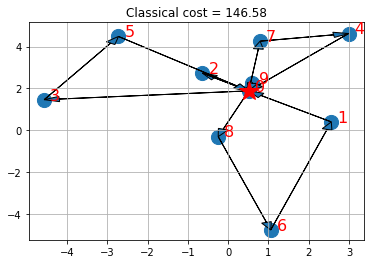

In [49]:
# Visualize the solution
def visualize_solution(xc, yc, x, C, n, K, title_str):
    plt.figure()
    plt.scatter(xc, yc, s=200)
    for i in range(len(xc)):
        plt.annotate(i, (xc[i] + 0.15, yc[i]), size=16, color="r")
    plt.plot(xc[0], yc[0], "r*", ms=20)

    plt.grid()

    for ii in range(0, n ** 2):

        if x[ii] > 0:
            ix = ii // n
            iy = ii % n
            plt.arrow(
                xc[ix],
                yc[ix],
                xc[iy] - xc[ix],
                yc[iy] - yc[ix],
                length_includes_head=True,
                head_width=0.25,
            )

    plt.title(title_str + " cost = " + str(int(C * 100) / 100.0))
    plt.show()


if x is not None:
    visualize_solution(xc, yc, x, classical_cost, n, K, "Classical")



## Coarsening VRP

### Coarsening Class

In [ ]:
from pygsp import *
from pygsp import graphs
from graph_coarsening.coarsening_utils import *
import graph_coarsening.graph_utils

def coarsen(
    G,
    K=10,
    r=0.5,
    max_levels=10,
    method="variation_neighborhood",
    algorithm="greedy",
    Uk=None,
    lk=None,
    max_level_r=0.99,
):
    """
    This function provides a common interface for coarsening algorithms that contract subgraphs

    Parameters
    ----------
    G : pygsp Graph
    K : int
        The size of the subspace we are interested in preserving.
    r : float between (0,1)
        The desired reduction defined as 1 - n/N.
    method : String
        ['variation_neighborhoods', 'variation_edges', 'variation_cliques', 'heavy_edge', 'algebraic_JC', 'affinity_GS', 'kron'] 
    
    Returns
    -------
    C : np.array of size n x N
        The coarsening matrix.
    Gc : pygsp Graph
        The smaller graph.
    Call : list of np.arrays
        Coarsening matrices for each level
    Gall : list of (n_levels+1) pygsp Graphs
        All graphs involved in the multilevel coarsening

    Example
    -------
    C, Gc, Call, Gall = coarsen(G, K=10, r=0.8)
    """
    r = np.clip(r, 0, 0.999)
    G0 = G
    N = G.N

    # current and target graph sizes
    n, n_target = N, np.ceil((1 - r) * N)

    C = sp.sparse.eye(N, format="csc")
    Gc = G

    Call, Gall = [], []
    Gall.append(G)

    g_coarsening_list = []
    g_iC = []

    for level in range(1, max_levels + 1):

        G = Gc

        # how much more we need to reduce the current graph
        r_cur = np.clip(1 - n_target / n, 0.0, max_level_r)

        if "variation" in method:

            if level == 1:
                if (Uk is not None) and (lk is not None) and (len(lk) >= K):
                    mask = lk < 1e-10
                    lk[mask] = 1
                    lsinv = lk ** (-0.5)
                    lsinv[mask] = 0
                    B = Uk[:, :K] @ np.diag(lsinv[:K])
                else:
                    offset = 2 * max(G.dw)
                    T = offset * sp.sparse.eye(G.N, format="csc") - G.L
                    lk, Uk = sp.sparse.linalg.eigsh(T, k=K, which="LM", tol=1e-5)
                    lk = (offset - lk)[::-1]
                    Uk = Uk[:, ::-1]
                    mask = lk < 1e-10
                    lk[mask] = 1
                    lsinv = lk ** (-0.5)
                    lsinv[mask] = 0
                    B = Uk @ np.diag(lsinv)
                A = B
            else:
                B = iC.dot(B)
                d, V = np.linalg.eig(B.T @ (G.L).dot(B))
                mask = d == 0
                d[mask] = 1
                dinvsqrt = d ** (-1 / 2)
                dinvsqrt[mask] = 0
                A = B @ np.diag(dinvsqrt) @ V

            if method == "variation_edges":
                coarsening_list = contract_variation_edges(
                    G, K=K, A=A, r=r_cur, algorithm=algorithm
                )
            else:
                coarsening_list = contract_variation_linear(
                    G, K=K, A=A, r=r_cur, mode=method
                )

        else:
            weights = get_proximity_measure(G, method, K=K)

            if algorithm == "optimal":
                # the edge-weight should be light at proximal edges
                weights = -weights
                if "rss" not in method:
                    weights -= min(weights)
                coarsening_list = matching_optimal(G, weights=weights, r=r_cur)

            elif algorithm == "greedy":
                coarsening_list = matching_greedy(G, weights=weights, r=r_cur)

        g_coarsening_list += [coarsening_list]
        iC = get_coarsening_matrix(G, coarsening_list)
        g_iC += [iC]

        if iC.shape[1] - iC.shape[0] <= 2:
            break  # avoid too many levels for so few nodes

        C = iC.dot(C)
        Call.append(iC)

        Wc = graph_utils.zero_diag(coarsen_matrix(G.W, iC))  # coarsen and remove self-loops
        Wc = (Wc + Wc.T) / 2  # this is only needed to avoid pygsp complaining for tiny errors

        if not hasattr(G, "coords"):
            Gc = gsp.graphs.Graph(Wc)
        else:
            Gc = gsp.graphs.Graph(Wc, coords=coarsen_vector(G.coords, iC))
        Gall.append(Gc)

        n = Gc.N

        if n <= n_target:
            break

    return C, Gc, Call, Gall, g_iC, g_coarsening_list

In [ ]:
def edge_list2dict(edge_list):
    n1, n2, w = edge_list
    assert len(n1) == len(n2) == len(w)
    return { (n1[i], n2[i]):w[i] for i in range(len(n1)) }

def rev_mapping(map):
    n1, n2 = map
    return (n2, n1)

def complete_mapping(mapping, child_edl):
    nodes = mapping.flatten()
    allnodes = set(flatten(child_edl))
    missing_nodes = set([ n for n in allnodes if n not in nodes ])
    for node in missing_nodes:
        mapping = np.insert(mapping, node, [node, node], axis=0)
    return mapping

def enforce_edl(parent_edl, child_edl, mapping):
    assert len(parent_edl) > len(child_edl)

    new_edl = {}
    mapping = complete_mapping(mapping, child_edl)
    for key, val in child_edl.items():
        # key = 1 <--> 0
        # val = (94.90546513274431)
        # parent_key = [7, 4] <--> [1, 0]
        # transformed_key = 7 <--> 1
        # transformed_key_val = parent(7 <--> 1)
        n1, n2 = key
        # print(n1, n2)
        x1,y1 = np.where(mapping[0:] == n1)
        x2,y2 = np.where(mapping[0:] == n2)

        x1, y1, x2, y2 = x1[0], y1[0], x2[0], y2[0]

        parent_key = mapping[x1], mapping[x2]
        transformed_key = mapping[x1][y1], mapping[x2][y2]
        transformed_key_val = parent_edl.get(transformed_key, parent_edl.get(rev_mapping(transformed_key)))
        new_edl[key] = transformed_key_val
    return new_edl

def flatten(lst):
    return [ n for nlist in lst for n in nlist]

def edl2w(edl):
    nodes = set(flatten(list(edl.keys())))
    X =  len(nodes)
    A = np.zeros((X,X))
    for key, value in edl.items():
        n1, n2 = key
        A[n1, n2] = value
        A[n2, n1] = value
    return A

import math

def get_cost(instance, n, K):
    # Instantiate the classical optimizer class
    classical_optimizer = ClassicalOptimizer(instance, n, K)
    x, classical_cost = classical_optimizer.cplex_solution()
    return x, classical_cost

def build_instance(nodelist, parent_edl):
    X = len(nodelist)
    A = np.zeros((X,X))
    for x in range(X):
        for y in range(X):
            if x!=y:
                NodeA = nodelist[x]
                NodeB = nodelist[y]
                A[x][y] = parent_edl.get((x,y), parent_edl.get((y,x)))
    return A, X

def get_subgraph_cost(sub_graph, parent_edl, K):
    assert len(sub_graph) == 2
    # x,y = sub_graph
    # value = parent_edl.get((x,y), parent_edl.get((y,x)))
    
    temp_instance, node_count = build_instance(sub_graph, parent_edl)
    sol, value = get_cost(temp_instance, node_count, min(K, math.ceil(node_count/2)))
    
    print(f"cost of the subgraph {sub_graph} is {value}")
    return value # multiplied with 2 means 2 way distance

### Test

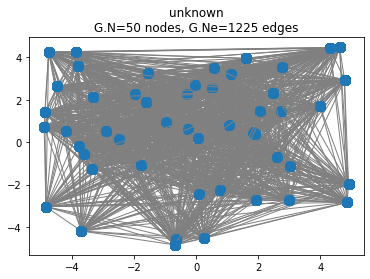

In [ ]:
G_pygsp = graphs.Graph(instance)
method = 'nearest'  

bak = G_pygsp
coords = np.array([xc, yc]).reshape((len(xc), 2))
bak.set_coordinates(coords)
bak.plot()

# print(bak.get_edge_list())

In [ ]:
C, Gc, Call, Gall, g_iC, g_coarsening_list = coarsen(bak, K=K, r=r, method=method, max_levels=1) 
metrics = coarsening_quality(G_pygsp, C, kmax=kmax)

# Check if coarsening was successful
assert len(Gall) > 1

coarsened_adjacency = Gall[1].W.toarray()
# coarsened_adjacency_unweighted = 1*np.array( coarsened_adjacency>1 )

print('{:16} | r: {:1.4}, nedges: {}, levels: {}, epsilon: {:1.4}'.format(method + " " + str(n), metrics['r'], metrics['m'], len(Call), metrics['error_subspace'][k-1]))

2022-02-10 06:26:08,221:[WARNING](pygsp.graphs.graph._check_fourier_properties): The Fourier basis G.U is not available, we need to compute the Fourier basis. Explicitly call G.compute_fourier_basis() once beforehand to suppress the warning.


nearest 50       | r: 0.2, nedges: 780, levels: 1, epsilon: 3.422e-05


##### Reset the coarsened distance with the original distance

In [ ]:
parent_edl = edge_list2dict(bak.get_edge_list())
child_edl   = edge_list2dict(Gc.get_edge_list())
mapping  = g_coarsening_list[0]

old_weight = Gc.W.toarray()

new_edl = enforce_edl(parent_edl, child_edl, mapping)
new_weight = edl2w(new_edl)
coarsened_adjacency_unweighted = new_weight

print(parent_edl)
print()
print(child_edl)

{(1, 0): 15.011098200257802, (2, 0): 1.7906289971006157, (2, 1): 17.060361252040103, (3, 0): 54.08126696652163, (3, 1): 54.9576738105024, (3, 2): 36.933246353751805, (4, 0): 56.30030099063749, (4, 1): 14.58293555334751, (4, 2): 54.17963047319412, (4, 3): 60.24078247333028, (5, 0): 10.472154727883439, (5, 1): 38.97776035533019, (5, 2): 4.849172372209258, (5, 3): 32.04405991986989, (5, 4): 83.29975632173583, (6, 0): 26.215242009610204, (6, 1): 5.5139549334800355, (6, 2): 22.346170340215163, (6, 3): 31.703197333031113, (6, 4): 7.699009503355125, (6, 5): 40.572590729870235, (7, 0): 6.196943360801884, (7, 1): 3.7869961490979525, (7, 2): 5.277954028154397, (7, 3): 36.846694638496075, (7, 4): 26.063630234490617, (7, 5): 18.66889005956407, (7, 6): 6.921279546253446, (8, 0): 19.66317153491932, (8, 1): 9.056561022118762, (8, 2): 13.767864907626015, (8, 3): 19.576031501042095, (8, 4): 17.837233272039008, (8, 5): 25.52909920454202, (8, 6): 2.2225094989020198, (8, 7): 4.677363013498697, (9, 0): 13.

In [ ]:
print('''

    0                   1                   2    3    4    5    6    7
    
0  [0.7071067811865475, 0.7071067811865475, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
1  [0.0, 0.0, 0.7071067811865475, 0.7071067811865475, 0.0, 0.0, 0.0, 0.0]
2  [0.0, 0.0, 0.0, 0.0, 0.0, 0.7071067811865475, 0.7071067811865475, 0.0]
3  [0.0, 0.0, 0.0, 0.0, 0.7071067811865475, 0.0, 0.0, 0.7071067811865475]
''')



    0                   1                   2    3    4    5    6    7
    
0  [0.7071067811865475, 0.7071067811865475, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
1  [0.0, 0.0, 0.7071067811865475, 0.7071067811865475, 0.0, 0.0, 0.0, 0.0]
2  [0.0, 0.0, 0.0, 0.0, 0.0, 0.7071067811865475, 0.7071067811865475, 0.0]
3  [0.0, 0.0, 0.0, 0.0, 0.7071067811865475, 0.0, 0.0, 0.7071067811865475]



In [ ]:
# np.set_printoptions(precision=2, suppress=True)

# [print( "\t".join([ '%.2f' % elem for elem in row ])) for row in coarsened_adjacency_unweighted]

# print()

In [ ]:
# np.set_printoptions(precision=2, suppress=True)

# [print( "\t".join([ '%.2f' % elem for elem in row ])) for row in coarsened_adjacency_unweighted]

# print()

Number of feasible solutions = 4368.0
cost of the subgraph [1 0] is 12.07384939412535
cost of the subgraph [16  2] is 12.07384939412535
cost of the subgraph [17  3] is 12.07384939412535
cost of the subgraph [15 14] is 12.07384939412535



The total cost for the VRP problem is 183.5516512766784




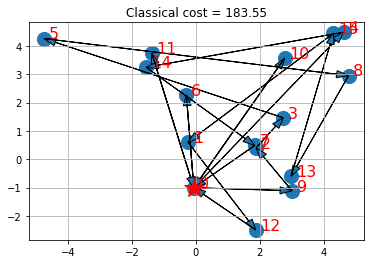

In [ ]:
# Classical Solution

# Instantiate the classical optimizer class
# classical_optimizer = ClassicalOptimizer(coarsened_adjacency, Gc.N, K)
classical_optimizer = ClassicalOptimizer(coarsened_adjacency_unweighted, Gc.N, K)

# Print number of feasible solutions
print('Number of feasible solutions = ' + str(classical_optimizer.compute_allowed_combinations()))

# Solve the problem in a classical fashion via CPLEX
x = None
z = None
try:
    x,classical_cost = classical_optimizer.cplex_solution()

    # Put the solution in the z variable
    z = [x[ii] for ii in range(Gc.N**2) if ii//Gc.N != ii%Gc.N]
    
except:
    print("CPLEX may be missing.")

(new_xc, new_yc) = (Gc.coords[:, 0], Gc.coords[:, 1])
total_classical_cost = classical_cost + sum([ get_subgraph_cost(sub_graph, parent_edl, K) for sub_graph in g_coarsening_list[0] ])

print('\n'*2)
print(f"The total cost for the VRP problem is {total_classical_cost}")

if x is not None:
    print('\n')
    visualize_solution(new_xc, new_yc, x, total_classical_cost, Gc.N, K, 'Classical')

In [ ]:
!git clone https://github.com/VGGatGitHub/QOSF-cohort3

Cloning into 'QOSF-cohort3'...
remote: Enumerating objects: 363, done.
remote: Counting objects: 100% (363/363), done.
remote: Compressing objects: 100% (274/274), done.
remote: Total 363 (delta 209), reused 201 (delta 83), pack-reused 0
Receiving objects: 100% (363/363), 5.85 MiB | 20.25 MiB/s, done.
Resolving deltas: 100% (209/209), done.


In [ ]:
!dwave config create --full

Updating existing configuration file: /root/.config/dwave/dwave.conf
Confirm configuration file path [/root/.config/dwave/dwave.conf]: 
Available profiles: defaults
Profile (select existing or create new) [defaults]: dev
Creating new profile: dev
Solver API region (na-west-1, eu-central-1) [skip]: 
Solver API endpoint URL (overwrites 'region') [skip]: 
Authentication token [skip]: DEV-07819bb244a52121ed70d4b8ec06d8dd82ab2efb
Client class (base, qpu, sw, hybrid) [skip]: 
Solver [skip]: 
Configuration saved.


In [ ]:
import sys
sys.path.append('./QOSF-cohort3/vehicle_routing')

import numpy as np
import utility

from full_qubo_solver import FullQuboSolver
from average_partition_solver import AveragePartitionSolver
from qiskit_native_solver import QiskitNativeSolver
from route_activation_solver import RouteActivationSolver
from clustered_tsp_solver import ClusteredTspSolver
from solution_partition_solver import SolutionPartitionSolver



In [ ]:
# fqs.solution.shape
fqs.evaluate_vrp_cost()

305.89553063362837

In [ ]:
dir(fqs)

/usr/local/lib/python3.7/dist-packages/dwave/system/samplers/leap_hybrid_sampler.py:264: UserWarning: bqm.iter_variables() is deprecated since dimod 0.10.0, use iter(bqm.variables) instead.
  mapping = dict(enumerate(bqm.iter_variables()))


Cost :  1412.5887126922607


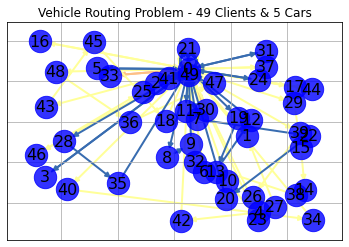

In [ ]:
fqs = FullQuboSolver(n-1, K, instance)
fqs.solve(solver='leap')
cost = fqs.evaluate_vrp_cost()
print("Cost : ", cost)
fqs.visualize(xc, yc)

cost of the subgraph [1 0] is 30.022196400515604
cost of the subgraph [40 39] is 30.022196400515604
cost of the subgraph [41  3] is 30.022196400515604
cost of the subgraph [42 35] is 30.022196400515604
cost of the subgraph [43 12] is 30.022196400515604
cost of the subgraph [36 34] is 30.022196400515604
cost of the subgraph [37  2] is 30.022196400515604
cost of the subgraph [38 33] is 30.022196400515604
cost of the subgraph [47 45] is 30.022196400515604
cost of the subgraph [48 17] is 30.022196400515604
coarsened Cost :  1602.9173023700714 Total Cost 1903.1392663752274


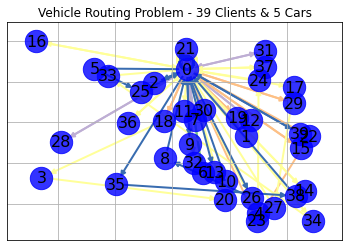

In [ ]:
fqs = FullQuboSolver(Gc.N-1, K, coarsened_adjacency_unweighted)
fqs.solve(solver='leap')
cost = fqs.evaluate_vrp_cost()
additional = sum([ get_subgraph_cost(sub_graph, parent_edl, K) for sub_graph in g_coarsening_list[0] ])
print("coarsened Cost : ", cost, "Total Cost", cost+additional)
fqs.visualize(xc, yc)